In [1335]:
# import all the necessary libraries
import os
import pysindy as ps
from pysindy.feature_library import CustomLibrary
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error

In [1520]:
# # The van der pol oscillator system (linear coupling)
# case = 'linear'
# x0 = [1, 0, 3, 0] # initial conditions
# def coupled_vdp_ac(t, x, lambda1=2, lambda2=2, omega1=1.5, omega2=1.5,epsilon=0.5):
#     return [x[1], 
#            lambda1 * (1-x[0]**2) * x[1] - omega1**2 * x[0] +  epsilon * (x[0]-x[2]),
#            x[3],
#            lambda2 * (1-x[2]**2) * x[3] - omega2**2 * x[2] + epsilon * (x[2]-x[0])]

# # The van der pol oscillator system (combination of linear and quadratic coupling)
# case = 'linear+quadratic'
# x0 = [1, 0, 3, 0] # initial conditions
# def coupled_vdp_ac(t, x, lambda1=2, lambda2=2,alpha1=1, alpha2=1, linear_coeff_1=0.3, linear_coeff_2=0.3, quadratic_coeff_1=0.1, quadratic_coeff_2=0.1):
#     return [x[1], 
#            lambda1 * (1-x[0]**2) * x[1] - alpha1 * x[0] + linear_coeff_1 * (x[0]-x[2]) +  quadratic_coeff_1 * (x[0]-x[2])**(2),
#            x[3],
#            lambda1 * (1-x[2]**2) * x[3] - alpha2 * x[2] + linear_coeff_2 * (x[2]-x[0]) + quadratic_coeff_1 * (x[2]-x[0])**(2)]

# # The van der pol oscillator system (exponential coupling)
# case = 'exponential'
# x0 = [1, -1, -3.5, 0.5] # initial conditions
# def coupled_vdp_ac(t, x, lambda1=1.6, lambda2=1.6, omega1=1.3, omega2=1.3, epsilon=0.5):
#     return [x[1], 
#            lambda1 * (1-x[0]**2) * x[1] - omega1**2 * x[0] +  epsilon * np.exp(-np.abs(x[0]-x[2])),
#            x[3],
#            lambda1 * (1-x[2]**2) * x[3] - omega2**2 * x[2] + epsilon * np.exp(-np.abs(x[2]-x[0]))]

# # The van der pol oscillator system (sinusoidal coupling)
# case = 'sinusoidal'
# x0 = [1, 0, 3, 0] # initial conditions
# def coupled_vdp_ac(t, x, lambda1=1.5, lambda2=1.5, omega1=1.2, omega2=1.2, epsilon=0.5):
#     return [x[1], 
#            lambda1 * (1-x[0]**2) * x[1] - omega1**2 * x[0] +  epsilon * np.sin(x[0]-x[2]),
#            x[3],
#            lambda1 * (1-x[2]**2) * x[3] - omega2**2 * x[2] + epsilon * np.sin(x[2]-x[0])]

# The van der pol oscillator system (sinusoidal+exponential coupling)
# case = 'sinusoidal+exponential'
# x0 = [1,0,3,0] # initial conditions
# def coupled_vdp_ac(t, x, lambda1=2, lambda2=2, omega1=1.2, omega2=1.2, epsilon=0.5):
#     return [x[1], 
#            lambda1 * (1-x[0]**2) * x[1] - omega1**2 * x[0] +  epsilon * np.sin(x[0]-x[2])*np.exp(-np.abs(x[0]-x[2])),
#            x[3],
#            lambda1 * (1-x[2]**2) * x[3] - omega2**2 * x[2] + epsilon * np.sin(x[2]-x[0])*np.exp(-np.abs(x[2]-x[0]))]

# The van der pol oscillator system (plain exponential coupling)
case = 'plain_exponential'
x0 = [1,0,3,0] # initial conditions
def coupled_vdp_ac(t, x, lambda1=2, lambda2=2, omega1=1.2, omega2=1.2, epsilon=0.5):
    return [x[1], 
           lambda1 * (1-x[0]**2) * x[1] - omega1**2 * x[0] +  epsilon * np.exp(x[0]-x[2]),
           x[3],
           lambda1 * (1-x[2]**2) * x[3] - omega2**2 * x[2] + epsilon * np.exp(x[2]-x[0])]



In [1521]:
# generate the data for testing
start = 0
end = 100
step = 0.01
t_span = [start, end]

sol = solve_ivp(coupled_vdp_ac, t_span, x0, dense_output=True)
t = np.arange(start, end+step/10, step)
x = sol.sol(t).T

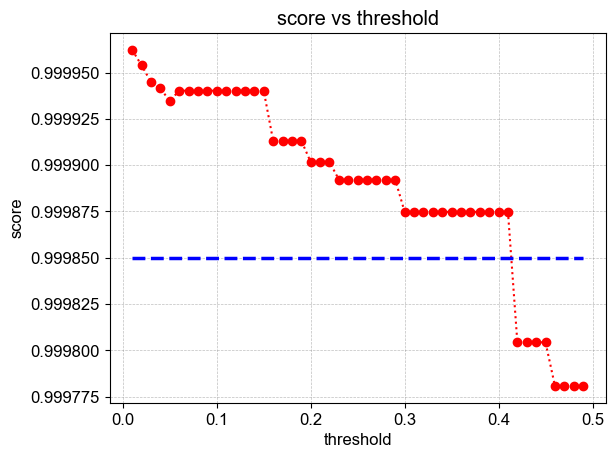

--------------------------------------------------
optimal_threshold: 0.41000000000000003
--------------------------------------------------
Identified model:
(x_1)' = 1.000 x_1dot
(x_1dot)' = -1.441 x_1 + 2.000 x_1dot + -1.999 x_1^2 x_1dot + 0.459 sin(x_1-x_2)*exp(-|x_1-x_2|)
(x_2)' = 1.000 x_2dot
(x_2dot)' = -1.448 x_2 + 2.011 x_2dot + -2.008 x_2^2 x_2dot + -0.473 sin(x_1-x_2)*exp(-|x_1-x_2|)


In [1529]:
# The feature names of the columns of y
feature_names = ['x_1', 'x_1dot', 'x_2', 'x_2dot']

# # Which feature library to use
# feature_library = ps.PolynomialLibrary(degree=3)



functions = [lambda x : x,
            lambda x: x**2,
            # lambda x: x**3,
            lambda x,y: x*y,
            lambda x,y: x**2*y,
            # lambda x,y: np.exp(-np.abs(x-y))
            # lambda x,y: np.sin(x-y)
            lambda x,y: np.sin(x-y)*np.exp(-np.abs(x-y))
            ]

function_names = [lambda x : str(x), 
                lambda x: str(x) + "^2",
                # lambda x: str(x) + "^3",
                lambda x,y: str(x)  + ' ' + str(y),
                lambda x,y: str(x) + "^2 " + str(y),
                # lambda x,y: 'exp(-|' + str(x) + '-' + str(y) + '|)'
                # lambda x,y: 'sin(' + str(x) + '-' + str(y) + ')'
                lambda x,y: 'sin(' + str(x) + '-' + str(y) + ')*exp(-|' + str(x) + '-' + str(y) + '|)',
                ]


lib_custom = CustomLibrary(library_functions=functions, 
                           function_names=function_names)
lib_custom.fit(x)
lib_custom.transform(x)

feature_library = lib_custom
# feature_library = ps.PolynomialLibrary(degree=3)


# Differentiation method
differentiation_method = ps.FiniteDifference(order=2)

scores = []

threshold_start = 0.01
threshold_end = 0.5
threshold_step = 0.01

thresholds = np.arange(threshold_start, threshold_end, threshold_step)

for threshold in thresholds:
    opt = ps.STLSQ(threshold=threshold)
    model=ps.SINDy(differentiation_method=differentiation_method,
                   feature_library = feature_library,
                   feature_names=feature_names, 
                  optimizer=opt)
    model.fit(x,t=t)
    scores.append(model.score(x,t=t))

score_threshold = 0.99985
threshold_line = np.ones(thresholds.shape) * score_threshold
plt.plot(thresholds, scores, 'ro:')
plt.plot(thresholds, threshold_line, 'b--', linewidth=2.5)
plt.xlabel('threshold')
plt.ylabel('score')
plt.title('score vs threshold')
plt.grid(True, linestyle='--', linewidth=0.5, color='gray', alpha=0.5)
plt.show()



optimal_threshold = None
for i in range(len(scores)):
    if scores[i] > score_threshold:
        optimal_threshold = thresholds[i]
    else:
        break

print('-'*50)
print(f'optimal_threshold: {optimal_threshold}')
print('-'*50)


# optimal_threshold = 0.2 # for testing

if optimal_threshold is None:
    raise ValueError('No threshold found that gives a score > score_threshold')
else:
    opt = ps.STLSQ(threshold=optimal_threshold)
    model=ps.SINDy(differentiation_method=differentiation_method,
                    feature_library = feature_library,
                    feature_names=feature_names,
                    optimizer=opt)
    model.fit(x,t=t)
    print('Identified model:')
    model.print()


In [1530]:
# Simulate the identified system 
sim = model.simulate(x0,t=t)

In [1531]:
directory = case + '_coupling'

if not os.path.exists(directory):
    os.makedirs(directory)

In [1532]:
def plot_comparison(t, true, identified,  xlabel, ylabel, figure_name):
    plt.plot(t, true, 'b', alpha=0.4, linewidth=2.5, label='True')
    plt.plot(t, identified, 'r--', linewidth=2.5, label='Identified')
    plt.xlabel(r"$" + xlabel + "$", fontsize=16)
    plt.ylabel(r"$" + ylabel + "$", fontsize=16)
    plt.legend(loc='upper right')
    plt.savefig(case + '_coupling/' + figure_name + '.pdf', format='pdf', dpi=300)
    # plt.grid(True, linestyle='--', linewidth=0.5, color='gray', alpha=0.5)
    plt.show()

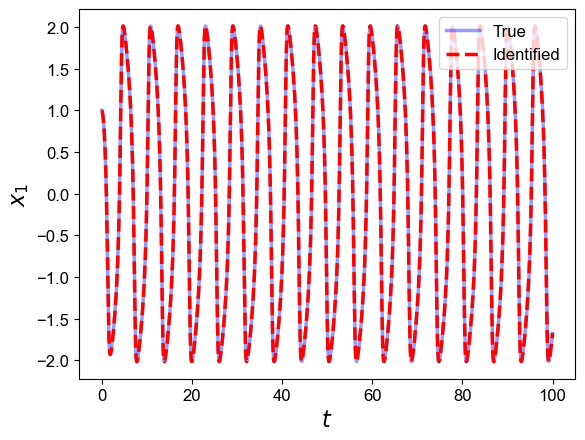

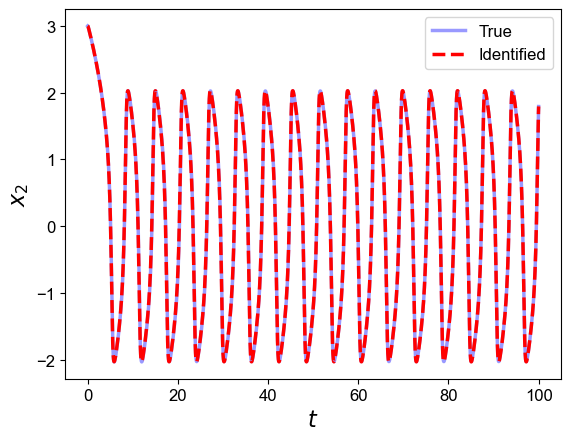

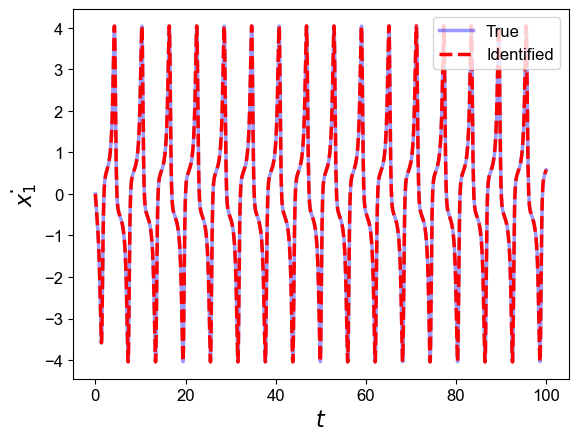

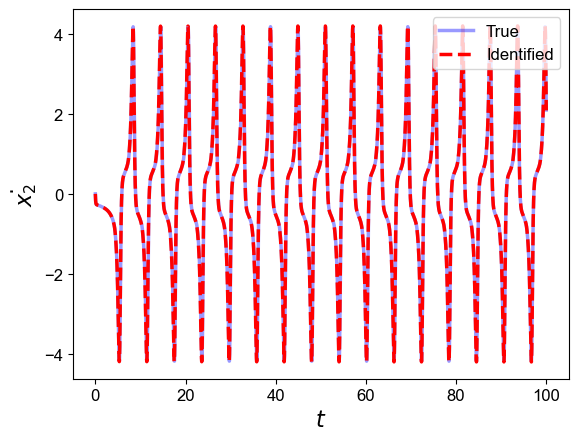

In [1533]:
# plot the solution

plt.rcdefaults()
plt.rcParams.update({'font.size': 12})

plt.rcParams['font.family'] = 'Sans-Serif'
plt.rcParams['font.sans-serif'] = ['Arial']

# x1
plot_comparison(t, x[:,0], sim[:,0], "t", "x_1", "x1_coupled_vdp")

# x2
plot_comparison(t, x[:,2], sim[:,2], "t", "x_2", "x2_coupled_vdp")

# x1 dot
plot_comparison(t, x[:,1], sim[:,1], "t", "\dot{x_1}", "x1dot_coupled_vdp")

# x2 dot
plot_comparison(t, x[:,3], sim[:,3], "t", "\dot{x_2}", "x2dot_coupled_vdp")

In [1534]:
def plot_pp(x, xdot, sim_x, sim_xdot, xlabel, ylabel, figure_name):
    plt.plot(x, xdot, 'b', alpha=0.6, linewidth=1, label='True')
    plt.plot(sim_x, sim_xdot, 'r--', linewidth=1, label='Identified')
    plt.xlabel(r"$" + xlabel + "$", fontsize=16)
    plt.ylabel(r"$" + ylabel + "$", fontsize=16)
    plt.legend(loc='upper right')
    plt.savefig(case + '_coupling/' + figure_name + '.pdf', format='pdf', dpi=300)
    # plt.grid(True, linestyle='--', linewidth=0.5, color='gray', alpha=0.5)
    plt.show()

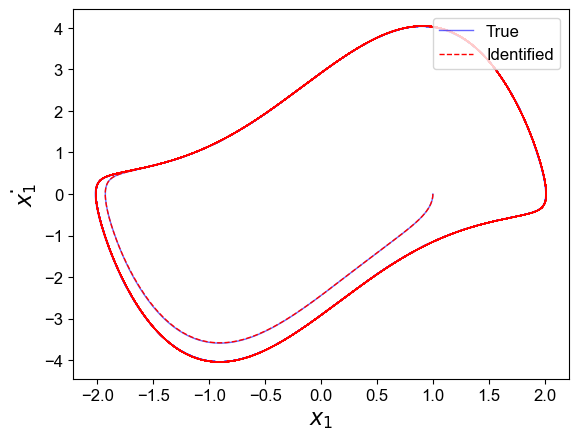

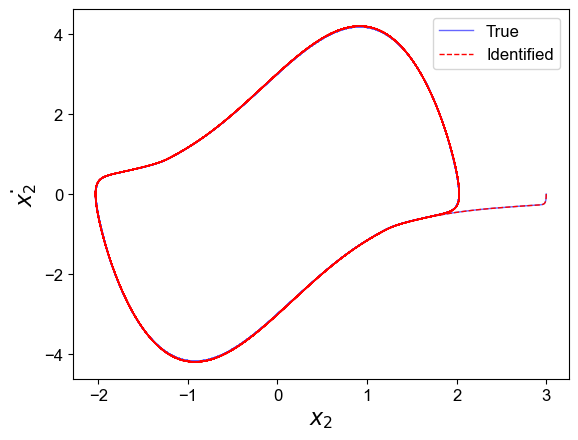

In [1535]:
# Phase Portrait Oscillator 1
plot_pp(x[:,0], x[:,1], sim[:,0], sim[:,1], "x_1", "\dot{x_1}", "pp_x1_vdp")

# Phase Portrait Oscillator 2
plot_pp(x[:,2], x[:,3], sim[:,2], sim[:,3], "x_2", "\dot{x_2}", "pp_x2_vdp")

In [1536]:
# Metrics
def get_metrics(x, sim, feature_names):
    metrics = {}
    for i, feature in enumerate(feature_names):
        metrics[feature] = {}
        metrics[feature]["R2"] = r2_score(x[:,i], sim[:,i])
        metrics[feature]["MSE"] = mean_squared_error(x[:,i], sim[:,i])
    return metrics

for metric in get_metrics(x, sim, feature_names):
    print(f'{metric}: {get_metrics(x, sim, feature_names)[metric]}')


x_1: {'R2': 0.9995809431861999, 'MSE': 0.0008935428148827797}
x_1dot: {'R2': 0.9984324313347287, 'MSE': 0.004741798882232693}
x_2: {'R2': 0.999383510989059, 'MSE': 0.001413565942909636}
x_2dot: {'R2': 0.9972819667395634, 'MSE': 0.008311848764810803}


In [1537]:
def plot_lissajous(x, xdot, xlabel, ylabel, figure_name):
    plt.plot(x, xdot, 'b', alpha=0.8, linewidth=2, label='True')
    plt.xlabel(r"$" + xlabel + "$", fontsize=16)
    plt.ylabel(r"$" + ylabel + "$", fontsize=16)
    plt.savefig(case + '_coupling/' + figure_name + '.pdf', format='pdf', dpi=300)
    # plt.grid(True, linestyle='--', linewidth=0.5, color='gray', alpha=0.5)
    plt.show()

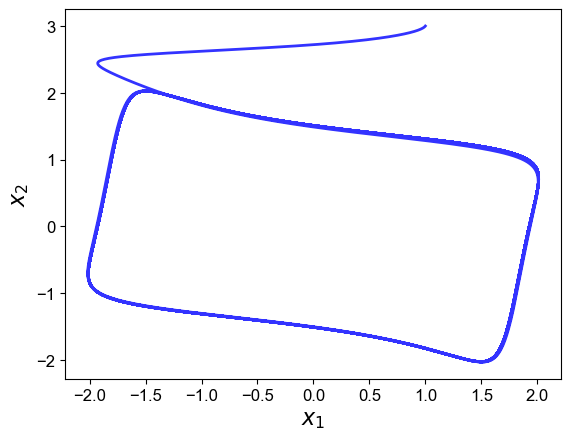

In [1538]:
# Displacement Lissajous Figure
plot_lissajous(x[:,0], x[:,2], "x_1", "x_2", "lissajous_disp_vdp")

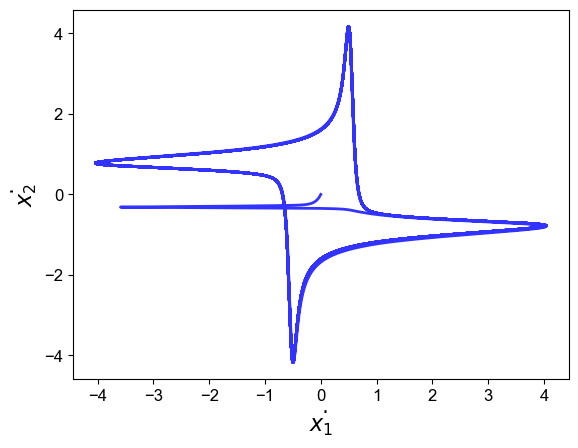

In [1539]:
# Velocity Lissajous Figure
plot_lissajous(x[:,1], x[:,3], "\dot{x_1}", "\dot{x_2}", "lissajous_vel_vdp")